## Prepare things (install, clone, import, folders, etc.)

### Install and clone dependencies

In [105]:
!pip install -q gymnasium #stable_baselines3

In [106]:
import os

repo_dir = "ai4r-gym"

if not os.path.exists(repo_dir):
    !git clone https://gitlab.unimelb.edu.au/ai4r/ai4r-gym.git

In [107]:
if not "AI4R-Aurora/ai4r-gym" in os.getcwd():
    %cd ai4r-gym

print(os.getcwd())

/home/sbongni/sources/unimelb/ai4r/AI4R-Aurora/ai4r-gym


### Library Imports

In [108]:
import ai4rgym
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
#from stable_baselines3 import PPO, SAC, DDPG
from utils import ensure_dir, ensure_dirs
#from utils import eval_model, evaluate_policy
#from utils import plot_rewards, plot_and_animate_trajectory

### Create a folder for saving figure

In [109]:
# Specify the policy name as a string
# > This is only used for naming the folder where results are saved
policy_name = "cone_following"

# Create the directories where the figures are saved
path_for_saving_figures = f"../models/{policy_name}/eval"
ensure_dir(path_for_saving_figures)

## Specify the Road


Specified as a list of dictionaries, where each
element in the list specifies a segment of the road.
Example segment dictionaries:
```Python
{"type":"straight", "length":3.0}
{"type":"curved", "curvature":1/50.0, "angle_in_degrees":45.0}
{"type":"curved", "curvature":1/50.0, "length":30.0}
```

In [110]:
road_elements_list = [
    {"type":"straight", "length":10.2},
    {"type":"curved", "curvature":1/5.0, "angle_in_degrees":90.0},
    {"type":"curved", "curvature":1/5.0, "angle_in_degrees":90.0},
    {"type":"straight", "length":4.0},
    {"type":"curved", "curvature":-1/10.0, "angle_in_degrees":45.0},
    {"type":"curved", "curvature":1/10.0, "angle_in_degrees":45.0},
    {"type":"curved", "curvature":1/4.0, "angle_in_degrees":90.0},
    {"type":"curved", "curvature":1/4.0, "angle_in_degrees":90.0},
    #{"type":"curved", "curvature":-1/4.0, "angle_in_degrees":90.0},
    #{"type":"curved", "curvature":1/3.8, "angle_in_degrees":90.0},
]

## Specify everything about the cones

### Specify the cone locations

Specified by the width between cones across the road, the length between cones on the same side of the road, and the standard deviation of the length between cones that are on the same side of the road.

In [111]:
# Specify the cone placement parameters
width_btw_cones = 1.0
mean_length_btw_cones = 0.5
stddev_of_length_btw_cones = 0.1

### Plot the road and cones to get a feel for what it looks like

We do this using a convenenience function.

Saved figure: ../models/cone_following/eval/ad_road_with_cones.pdf


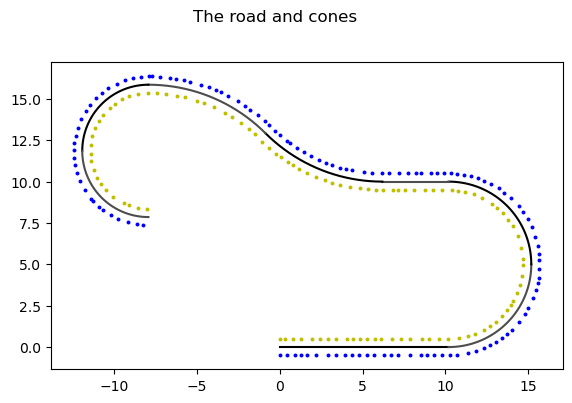

In [112]:
# Import the funcion
from evaluation.evaluation_for_autonomous_driving import plot_road_from_list_of_road_elements

# Specify a suffix for the plot file names
file_name_suffix = "with_cones"

# Call the plotting function
road_plot_details = plot_road_from_list_of_road_elements(road_elements_list, path_for_saving_figures, file_name_suffix, width_btw_cones=width_btw_cones, mean_length_btw_cones=mean_length_btw_cones, stddev_of_length_btw_cones=stddev_of_length_btw_cones)

### Specify the details of generating cone observation

These specifications are described in the the "AI4R_Gym_Observations_Explanation.pdf" file that is provided on [Workshop Material page](https://canvas.lms.unimelb.edu.au/courses/187349/pages/workshop-materials-2) on LMS

In [113]:
cone_detections_fov_horizontal_degrees         =  80.0
cone_detections_body_x_upper_bound             =  4.0
cone_detections_stddev_of_detection_in_body_x  =  0.2
cone_detections_stddev_of_detection_in_body_y  =  0.1

## Environment Settings

**IMPORTANT NOTE**

The steering offset parameter in the bicycle model is set to 0 degrees, i.e., `"delta_offset" : 0.0 * np.pi/180,`.

This steering offset can be an important parameter to consider for matching simulation peformance and real-world behaviour.

### Specify the Vehicle Parameters

Dictionary with car specifications,
in the form of a dynamic bicycle model.

The model parameters values here are very loosely intended to match a 1/10 scale Traxxas Slash RC car.

In [114]:
# SPECIFY THE VEHCILE PARAMETERS
bicycle_model_parameters = {
    "Lf" : 0.60*0.33,
    "Lr" : 0.40*0.33,
    "m"  : 3.0,
    "Iz" : (1.0/12.0) * 3.0 * (0.40**2+0.25**2),
    "Cm" : (1.0/100.0) * 10.0,
    "Cd" : 1.0,
    "delta_offset" : 0.0 * np.pi/180,
    "delta_request_max" : 45 * np.pi/180,
    "Ddelta_lower_limit" : -90 * np.pi/180,
    "Ddelta_upper_limit" :  90 * np.pi/180,
    "v_transition_min" : 500.0 / 3.6,
    "v_transition_max" : 600.0 / 3.6,
    "body_len_f" : (0.60*0.33) * 1.5,
    "body_len_r" : (0.40*0.33) * 1.5,
    "body_width" : 0.25,
}

### Specify the Observation Parameters

To make this more precise, we have remove the parameters that are not necessary for this example. Those parameters that are left out are automatically set to default values by the Gymnasium.

In [115]:
# SPECIFY THE OBSERVATION PARAMETERS
observation_parameters = {
    "should_include_ground_truth_px"                       :  "info",
    "should_include_ground_truth_py"                       :  "info",
    "should_include_ground_truth_theta"                    :  "info",
    "should_include_ground_truth_vx"                       :  "info",
    "should_include_ground_truth_vy"                       :  "info",
    "should_include_ground_truth_omega"                    :  "info",
    "should_include_ground_truth_delta"                    :  "info",
    "should_include_road_progress_at_closest_point"        :  "info",
    "should_include_vx_sensor"                             :  "info",
    "should_include_distance_to_closest_point"             :  "obs",
    "should_include_heading_angle_relative_to_line"        :  "obs",
    "should_include_heading_angular_rate_gyro"             :  "info",
    "should_include_closest_point_coords_in_body_frame"    :  "info",
    "should_include_look_ahead_line_coords_in_body_frame"  :  "neither",
    "should_include_road_curvature_at_closest_point"       :  "neither",
    "should_include_look_ahead_road_curvatures"            :  "neither",
    "should_include_cone_detections"                       :  "obs",
    "should_include_recommended_speed"                     :  "info",

    "vx_sensor_bias"    : 0.0,
    "vx_sensor_stddev"  : 0.0, #0.1

    "cone_detections_width_btw_cones"             :  width_btw_cones,
    "cone_detections_mean_length_btw_cones"       :  mean_length_btw_cones,
    "cone_detections_stddev_of_length_btw_cones"  :  stddev_of_length_btw_cones,

    "cone_detections_fov_horizontal_degrees"         :  cone_detections_fov_horizontal_degrees,
    "cone_detections_body_x_upper_bound"             :  cone_detections_body_x_upper_bound,
    "cone_detections_stddev_of_detection_in_body_x"  :  cone_detections_stddev_of_detection_in_body_x,
    "cone_detections_stddev_of_detection_in_body_y"  :  cone_detections_stddev_of_detection_in_body_y,
}

###  Specify the Initial State Distribution

The initial state is sampled from a uniform
distribution between the minimum and maximum
(i.e., between lower and upper bounds)
> Note: a factor of (1/3.6) converts from units of [km/h] to [m/s]

In [116]:
py_init_min = -0.1
py_init_max =  0.1

v_init_min_in_meters_per_sec = 1.0
v_init_max_in_meters_per_sec = 1.0

initial_state_bounds = {
    "px_init_min" : 0.0,
    "px_init_max" : 0.0,
    "py_init_min" : py_init_min,
    "py_init_max" : py_init_max,
    "theta_init_min" : 0.0,
    "theta_init_max" : 0.0,
    "vx_init_min" : v_init_min_in_meters_per_sec,
    "vx_init_max" : v_init_min_in_meters_per_sec,
    "vy_init_min" : 0.0,
    "vy_init_max" : 0.0,
    "omega_init_min" : 0.0,
    "omega_init_max" : 0.0,
    "delta_init_min" : 0.0,
    "delta_init_max" : 0.0,
}

### Specify Termination Parameters

In [117]:
termination_parameters = {
    "speed_lower_bound"  :  0.0,
    "speed_upper_bound"  :  10.0,
    "distance_to_closest_point_upper_bound"  :  20.0,
    "reward_speed_lower_bound"  :  0.0,
    "reward_speed_upper_bound"  :  0.0,
    "reward_distance_to_closest_point_upper_bound"  :  0.0,
}

### Specify the Numerical Integration Details

The options available for the numerical
integration method are:
`["euler", "huen", "midpoint", "rk4", "rk45"]`


In [118]:
numerical_integration_parameters = {
    "method" : "rk4",
    "Ts" : 0.05,
    "num_steps_per_Ts" : 1,
}

## Initialise the Autonomous Driving Environment

Options available for the "render_mode" are:
`["matplotlib", None]`

In [119]:
env_base = gym.make(
    "ai4rgym/autonomous_driving_env",
    render_mode=None,
    bicycle_model_parameters=bicycle_model_parameters,
    road_elements_list=road_elements_list,
    numerical_integration_parameters=numerical_integration_parameters,
    termination_parameters=termination_parameters,
    initial_state_bounds=initial_state_bounds,
    observation_parameters=observation_parameters,
)

### Verify Environment

In [120]:
# Reset the gymnasium
# > which also returns the first observation
observation, info_dict = env_base.reset()

/home/sbongni/anaconda3/envs/ai4r/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be float32, actual type: float64
  logger.warn(
/home/sbongni/anaconda3/envs/ai4r/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


In [121]:
observation

{'distance_to_closest_point': array([0.06979174], dtype=float32),
 'heading_angle_relative_to_line': array([0.], dtype=float32),
 'cone_detections_x': array([0.97198637, 1.34794451, 1.69893861, 2.32072304, 2.37057704,
        3.33598167, 0.53611383, 1.39082223, 2.0270743 , 1.99447143,
        3.09576027, 3.14163632, 3.52782938, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ]),
 'cone_detections_y': array([ 0.25117593,  0.3501215 ,  0.41628617,  0.52978798,  0.4196789 ,
         0.39872122, -0.51174234, -0.5557824 , -0.7202982 , -0.61346418,
        -0.62729247, -0.58478572, -0.6173221 ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ]),
 'cone_detections_side_of_road': array([0, 0, 0, 0, 0,

In [122]:
info_dict

{'ground_truth_px': array([0.], dtype=float32),
 'ground_truth_py': array([0.06979174], dtype=float32),
 'ground_truth_theta': array([0.], dtype=float32),
 'ground_truth_vx': array([1.], dtype=float32),
 'ground_truth_vy': array([0.], dtype=float32),
 'ground_truth_omega': array([0.], dtype=float32),
 'ground_truth_delta': array([0.], dtype=float32),
 'road_progress_at_closest_point': array([-1.9073487e-07], dtype=float32),
 'vx_sensor': array([1.], dtype=float32),
 'steering_angle_sensor': array([0.], dtype=float32),
 'heading_angular_rate_gyro': array([0.], dtype=float32),
 'closest_point_coords_in_body_frame': array([ 0.        , -0.06979174], dtype=float32),
 'speed_limit': array([27.777779], dtype=float32),
 'recommended_speed': array([27.777779], dtype=float32),
 'next_speed_limit': array([27.777779], dtype=float32),
 'distance_to_next_speed_limit': array([1.9073487e-07], dtype=float32),
 'next_recommended_speed': array([27.777779], dtype=float32),
 'distance_to_next_recommended_

In [123]:
env_base.observation_space

Dict('cone_detections_num_cones': MultiDiscrete([28]), 'cone_detections_side_of_road': MultiDiscrete([3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]), 'cone_detections_x': Box(-inf, inf, (27,), float32), 'cone_detections_y': Box(-inf, inf, (27,), float32), 'distance_to_closest_point': Box(-inf, inf, (1,), float32), 'heading_angle_relative_to_line': Box(-3.1415927, 3.1415927, (1,), float32))

In [124]:
env_base.action_space

Box([-100.          -0.7853982], [100.          0.7853982], (2,), float32)

In [125]:
random_action = env_base.action_space.sample()

In [126]:
observation, reward, terminated, truncated, info = env_base.step(random_action)

In [127]:
observation

{'distance_to_closest_point': array([0.07064234], dtype=float32),
 'heading_angle_relative_to_line': array([-0.00574177], dtype=float32),
 'cone_detections_x': array([1.134278  , 1.7454331 , 1.9666572 , 2.3566885 , 2.852325  ,
        3.11611   , 0.78164744, 1.1749097 , 1.7758346 , 2.2728798 ,
        2.458405  , 3.1754365 , 3.7305324 , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ], dtype=float32),
 'cone_detections_y': array([ 0.27096754,  0.5567604 ,  0.4627069 ,  0.54451656,  0.45620197,
         0.44534576, -0.42290685, -0.44656086, -0.38749552, -0.59615   ,
        -0.6666432 , -0.7048609 , -0.68957543,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ], dtype=float32),
 'cone_detectio

In [128]:
reward

0.0

In [129]:
info

{'ground_truth_px': array([0.04864627], dtype=float32),
 'ground_truth_py': array([0.07064234], dtype=float32),
 'ground_truth_theta': array([0.00574177], dtype=float32),
 'ground_truth_vx': array([0.9462348], dtype=float32),
 'ground_truth_vy': array([0.02978813], dtype=float32),
 'ground_truth_omega': array([0.22566764], dtype=float32),
 'ground_truth_delta': array([0.07853982], dtype=float32),
 'road_progress_at_closest_point': array([0.04864608], dtype=float32),
 'vx_sensor': array([0.9462348], dtype=float32),
 'steering_angle_sensor': array([0.07853982], dtype=float32),
 'heading_angular_rate_gyro': array([0.22566764], dtype=float32),
 'closest_point_coords_in_body_frame': array([-0.00040561, -0.07064117], dtype=float32),
 'speed_limit': array([27.777779], dtype=float32),
 'recommended_speed': array([27.777779], dtype=float32),
 'next_speed_limit': array([27.777779], dtype=float32),
 'distance_to_next_speed_limit': array([10.151354], dtype=float32),
 'next_recommended_speed': arra

## Define a Policy Class for Cone Following

This is the same policy that is provide in the policy_node.py of the ai4r-system git repository.

As explaining during class, this policy is provided to show you the definitions, the use, and the flow of data.

Once you feel comfortable with the observation and action data, then you should delete this policy and develop your own policy from scratch.

In [130]:
## ---------------------
#  DEFINE A POLICY CLASS
#  ---------------------

SIM_TO_REAL_CONV = 1e-3

class PIDPolicyForConeFollowing:
    """
    This class implements a policy for Autonomus Driving
    that mostly matches the policy provided in the policy_node
    """

    def __init__(self):
        """
        Initialization function for the "PIDPolicyForAutonomousDriving" class.
        """
        self.speed_ref = 10.0
        self.drive_command_baseline = 10.0
        self.kp_cruise_control = 4.0
        
        self.prev_lateral_error = 0.0
        self.integral_lateral_error = 0.0

        self.timer_period = 0.05  # seconds per control step (example)



    def reset(self):
        self.prev_lateral_error = 0.0
        self.integral_lateral_error = 0.0

    
    def compute_action(self, observation, info_dict, terminated, truncated):
        # Set the speed reference
        speed_ref = self.speed_ref
        # Zero speed reference after reaching the end of the road
        if (terminated or truncated):
            speed_ref = 0.0

        # Simple Proportional-only controll for speed control
        # > Get the speed observation of the car
        # speed = observation["vx_sensor"][0]
        # > Compute the error between the reference and actual speed
        # speed_error = speed_ref - speed
        # > Compute the drive command action
        # drive_command_raw = self.drive_command_baseline + self.kp_cruise_control * speed_error
        # > Clip the drive command action to be in the range [-100,100] percent
        # drive_command_clipped = max(-100.0, min(drive_command_raw, 100.0))

        # Initialise the steering request to zero
        delta_request = 0.0

        # Extract the number of cones
        num_cones = observation["cone_detections_num_cones"][0]
        # > On the real car, this is:
        #num_cones = msg.n

        # Extract the coordinates and colour of each cone
        # > Note: multiplying by 1000.0 to convert from meters to millimeters
        x_coords_np_array = observation["cone_detections_x"][:num_cones] * 1000.0
        y_coords_np_array = observation["cone_detections_y"][:num_cones] * 1000.0
        x_coords = x_coords_np_array.tolist()
        y_coords = y_coords_np_array.tolist()
        
        # + COMMENTED: Colours are not considered anymore - instead, LEFT or RIGHT
        cone_colour = observation["cone_detections_side_of_road"][:num_cones].tolist()

        # + Heading Angle (in rads)
        heading_angle_in_radians = observation["heading_angle_relative_to_line"][0]

        # > On the real car, this is:
        #x_coords = msg.x
        #y_coords = msg.y
        #cone_colour = msg.c

        # =======================================
        # START OF: INSERT POLICY CODE BELOW HERE
        # =======================================

        # OBSERVATIONS:
        # > The "x_coords", "y_coords" and "cone_colour" variable are:
        #   - Lists with length equal to num_cones (the number of cones detected).
        #   - "x_coords" and "y_coords" give the x and y world coordinates of the cones respectively
        #   - "cone_colour" gives the colour of the cones (0 for yellow, 1 for blue)
        #   - A cone represents a single index of all three lists e.g. x_coords[i], y_coords[i], cone_colour[i] represent the ith cone

        # ACTIONS:
        # > The "esc_action" is:
        #   - The action for driving the main motor (esc := electronic speed contrller).
        #   - In units of signed percent, with valid range [-100,100]
        # > The "steering_action" is:
        #   - The action for changing the position of the steering servo.
        #   - In units of signed percent, with valid range [-100,100]

        # ACRONYMS:
        # "esc" := Electronic Speed Controller
        #   - This device on the Traxxas car does NOT control the speed.
        #   - The "esc" device set the voltage to the motor within the
        #     range [-(max voltage),+(max voltage)]

        # ===============================================================================================================
        #                                               AMAZING POLICY
        # ===============================================================================================================

        # ---------------------------------------------------------------------------------------------------------------
        #                                           VARIABLES AND CONSTANTS
        # ---------------------------------------------------------------------------------------------------------------

        # + PID and Gain values
        P_STEERING = SIM_TO_REAL_CONV * 0.2        # P value for Steering Action; DEFAULT=0.1
        I_STEERING = SIM_TO_REAL_CONV * 0.0025     # I value for Steering Action; DEFAULT=0.0
        I_ADAPTION = SIM_TO_REAL_CONV * 0.9        # + Adaption rate for the integral term; DEFAULT=0.9
        D_STEERING = SIM_TO_REAL_CONV * 0.0025      # D value for Steering Action; DEFAULT=0.01
        HEADING_GAIN = SIM_TO_REAL_CONV * 0.2      # + Gain for heading error correction; DEFAULT=0.5

        # + Steering Adjustment Values
        STEER_OFFSET = 0        # Offset to adjust for biased steering; DETAULT=0
        FIXED_ESC_VALUE = 15.0  # Fixed ESC value for steering tests; DEFAULT=33.0

        # + Lookahead Window Definition(in mm)
        X_MIN = 200.0           # Start of lookahead window; SIMULATION=500.0
        X_MAX = 2_000.0         # End of lookahead window; SIMULATION=8_000.0
        X_LOOKAHEAD = 800.0     # Lookahead point (where we aim to be in the centre of the road); SIMULATION=1_000.0
        ANGLE_THRESHOLD = 0.0   # Max heading angle (in degrees) to consider INVALID cone detections [-10°, +10°]; DETAULT=10.0

        # ---------------------------------------------------------------------------------------------------------------
        #                                               HELPER FUNCTIONS
        # ---------------------------------------------------------------------------------------------------------------

        # + Filter cones based on Lookahead Window and Front View Restrictions
        def filter_forward_cones(x_coords, y_coords, cone_colour):
            # Convert to arrays for convenience
            x_array = np.array(x_coords, dtype=float)  # Forward (in mm)
            y_array = np.array(y_coords, dtype=float)  # Lateral (in mm)
            c_array = np.array(cone_colour, dtype=int)  # Colour (0=yellow, 1=blue)

            # + Apply forward window (we only get the cones values within range)
            window_mask = (x_array >= X_MIN) & (x_array <= X_MAX)
            x_window, y_window, c_window = x_array[window_mask], y_array[window_mask], c_array[window_mask]

            # + Compute angle θ = atan2(y, x) for each cone within the window
            theta = np.arctan2(y_window, x_window)  # In radians

            # + Apply front view restriction (we only keep cones within the angle threshold)
            angle_mask = np.abs(np.degrees(theta)) > ANGLE_THRESHOLD

            return x_window[angle_mask], y_window[angle_mask], c_window[angle_mask]
        

        # + Compute dominant road direction using PCA
        def compute_PCA_road_direction(x, y):
            # + If enough info, we assume forwards direction
            if len(x) < 2:
                return np.array([1.0, 0.0])  

            # + Prepare points for PCA
            pts = np.column_stack((x, y)).astype(float)
            mean = np.mean(pts, axis=0)
            centered = pts - mean
            
            # + Compute covariance matrix and its eigenvalues/vectors
            cov = np.cov(centered.T)
            eigvals, eigvecs = np.linalg.eig(cov)
            principal_axis = eigvecs[:, np.argmax(eigvals)]  # Principal axis corresponds to largest eigenvalue

            # + Ensure principal axis points forwards (positive x direction)
            if principal_axis[0] < 0:
                principal_axis = -principal_axis

            return principal_axis / np.linalg.norm(principal_axis)  # Normalize
        
        # + Compute lateral error to target line at lookahead point
        def compute_lateral_error(x_left, y_left, x_right, y_right, y_pca_target):
            # + Check if we have valid cones on both sides
            has_left_cones, has_right_cones = len(x_left) > 0, len(x_right) > 0

            # + Find the nearest LEFT and RIGHT CONES near the LOOKAHEAD 
            x_left_distances = np.abs(np.array(x_left) - X_LOOKAHEAD)
            x_right_distances = np.abs(np.array(x_right) - X_LOOKAHEAD)
            
            if has_left_cones and has_right_cones:
                # + Pick closest in x-forward to lookahead
                x_left_closest  = np.argmin(x_left_distances)
                x_right_closest = np.argmin(x_right_distances)
                # + Compute center between the two cones
                return 0.5 * (y_left[x_left_closest] + y_right[x_right_closest])
            else:
                return y_pca_target  # Default to target line if insufficient cones

        # ---------------------------------------------------------------------------------------------------------------
        #                                                 POLICY LOGIC
        # ---------------------------------------------------------------------------------------------------------------

        # + FILTER the cones to only keep those in FRONT of the car within the lookahead window
        x, y, c = filter_forward_cones(x_coords, y_coords, cone_colour)

        # + COMPUTE DOMINANT ROAD DIRECTION using PCA
        road_direction = compute_PCA_road_direction(x, y)

        # + SEPARATE BLUE cones (left) and YELLOW cones (right)
        x_left, y_left, x_right, y_right = x[c == 1], y[c == 1], x[c == 0], y[c == 0]

        # + Use PCA road direction to choose LOOKAHEAD TARGET POINT
        # x_pca_target = X_LOOKAHEAD * road_direction[0] <- Not needed
        y_pca_target = X_LOOKAHEAD * road_direction[1]

        # + COMPUTE LATERAL ERROR to the target line at LOOKAHEAD TARGET POINT
        lateral_error = compute_lateral_error(x_left, y_left, x_right, y_right, y_pca_target)

        # + COMPUTE ERRORS for STEERING ACTION
        heading_error = np.arctan2(road_direction[1], road_direction[0])  # HEADING ERROR to the road direction (in radians)
        derivative_error = (lateral_error - self.prev_lateral_error) / self.timer_period
        # + UPDATE INTEGRAL of lateral error with ADAPTION
        self.integral_lateral_error = ((1 - I_ADAPTION) * self.integral_lateral_error 
                                           + I_ADAPTION * lateral_error * self.timer_period)

        # + STEERING AND ESC ACTIONS
        steering_action = (
            P_STEERING * lateral_error                  # P term for lateral error
            + I_STEERING * self.integral_lateral_error  # I term for lateral error
            + D_STEERING * derivative_error             # D term for lateral error
            + HEADING_GAIN * np.degrees(heading_error)  # Heading error correction (PCA-based)
            + STEER_OFFSET)
        
        drive_command_clipped = FIXED_ESC_VALUE  # Keep forward motion

        # + UPDATE previous lateral error
        self.prev_lateral_error = lateral_error

        # ===============================================================================================================
        #                                               END OF THE POLICY
        # ===============================================================================================================


        # Convert the [-100,100] percentage stering action
        # into a steering angle
        steering_action_clipped = max(-90.0, min(steering_action, 90.0))
        delta_request = steering_action_clipped * bicycle_model_parameters["delta_request_max"]
    
        # Construct the action vector expected by the gymnasium
        action = np.array([drive_command_clipped,delta_request], dtype=np.float32)
    
        # Return the action
        return action

In [131]:
## ---------------------
#  DEFINE A POLICY CLASS
#  ---------------------

USE_RL = True

class RLWrapper(gym.Wrapper):
    """
    This class implements a policy for Autonomus Driving
    that mostly matches the policy provided in the policy_node
    """

    def __init__(self, env, pid: PIDPolicyForConeFollowing):
        """
        Initialization function for the "PIDPolicyForAutonomousDriving" class.
        """
        super().__init__(env)
        
        self.pid = pid

        self.obs = {}
        self.info = {}
        self.terminated = False
        self.truncated = False


    
    def reset(self, **kwargs):
        self.pid.reset()

        obs, info = self.env.reset(**kwargs)
        
        self.obs = obs
        self.info = info
        self.terminated = False
        self.truncated = False

        return obs, info



    def step(self, rl_action):
        rl_residual = np.clip(np.asarray(rl_action) * SIM_TO_REAL_CONV, self.env.action_space.low, self.env.action_space.high)

        u_pid = self.pid.compute_action(self.obs, self.info, self.terminated, self.truncated)

        combined = np.asarray(u_pid) + rl_residual
        combined = np.clip(combined, self.env.action_space.low, self.env.action_space.high)

        obs, reward, terminated, truncated, info = self.env.step(combined if USE_RL else u_pid)

        self.obs = obs
        self.info = info
        self.terminated = terminated
        self.truncated = truncated

        return obs, reward, terminated, truncated, info
        


    def render(self, *args, **kwargs):
        return self.env.render(*args, **kwargs)


### Reward Wrapper

We set the reward equal to zero because the reward function is not the focus of this example notebook. Hence, setting the reward to zero hopefully make the reward less of a distraction.

In [132]:
class RewardWrapper(gym.Wrapper):
    def __init__(self, env):
        super(RewardWrapper, self).__init__(env)
        self.prev_delta = np.nan

    def step(self, action):
        observation, reward, terminated, truncated, info = self.env.step(action)

        num_cones = observation["cone_detections_num_cones"][0]
        y_coords_np_array = observation["cone_detections_y"][:num_cones]
        
        y = np.array(y_coords_np_array.tolist(), dtype=float)  # Forward (in mm)
        c = np.array(observation["cone_detections_side_of_road"][:num_cones].tolist(), dtype=int)  # Colour (0=yellow, 1=blue)

        # + SEPARATE BLUE cones (left) and YELLOW cones (right)
        y_left, y_right = y[c == 1], y[c == 0]

        reward = 0.0

        d = observation["distance_to_closest_point"]
        delta = observation["heading_angle_relative_to_line"]
        d_t = self.env.pid.timer_period

        delta_derivative = 0.0
        if not np.isnan(self.prev_delta):
            delta_derivative = (self.prev_delta - delta) / d_t
            self.prev_delta = delta

        coeff = 1.0
        if len(y_left) > 0 and len(y_right) > 0:
            road_size = np.abs(y_left[0] - y_right[0])
            coeff = 1.0 / (1.0 + max(0.0, d - road_size))

        distance_reward = 0.5 / (1.0 + d**2) 
        heading_reward = 0.5 / (1.0 + delta**2) + 0.0 / (1.0 + delta_derivative**2)

        reward = distance_reward + coeff * heading_reward

        return observation, reward, terminated, truncated, info

Create a new environment and wrap it with the Reward Wrapper

In [133]:
def generate_env():
    env_base = gym.make(
        "ai4rgym/autonomous_driving_env",
        render_mode=None,
        bicycle_model_parameters=bicycle_model_parameters,
        road_elements_list=road_elements_list,
        numerical_integration_parameters=numerical_integration_parameters,
        termination_parameters=termination_parameters,
        initial_state_bounds=initial_state_bounds,
        observation_parameters=observation_parameters,
    )

    # Set the road condition
    env_base.unwrapped.set_road_condition(road_condition="dry")

    # Initialize the Cone Following Policy class
    cone_following_policy = PIDPolicyForConeFollowing()

    env_rl_wrapper = RLWrapper(env=env_base, pid=cone_following_policy)

    # Add the reward wrapper
    return RewardWrapper(env_rl_wrapper)

Print reward

In [134]:
env_reward = generate_env()

observation, info = env_reward.reset()
random_action = env_reward.action_space.sample()
observation, reward, terminated, truncated, info = env_reward.step(random_action)
print(reward)

[0.996465]


### Train the policy

In [135]:
import math
import random

from ai4rgym.envs.road import Road



road_randomization_params = {
    'num_elements_range': (1, 10),             # Highly variable number of road elements
    'straight_length_range': (1.0, 20.0),    # Straight segments can be very short or long
    'curvature_range': (-1/4.0, 1/4.0),      # Very tight curves possible
    'angle_range': (10.0, 90.0)                # Wide range of angles for curves
}



class DomainRandomizationWrapper(gym.Wrapper):
    def __init__(self, env, road_randomization_params=None, seed=None):
        super(DomainRandomizationWrapper, self).__init__(env)
        self.road_randomization_params = road_randomization_params
        if seed is not None:
            random.seed(seed)

    def generate_random_road_elements_list(self):
        params = self.road_randomization_params or {}
        num_elements_range = params.get('num_elements_range', (2, 5))
        straight_length_range = params.get('straight_length_range', (1.0, 10.0))
        curvature_range = params.get('curvature_range', (-1/500.0, 1/500.0))
        angle_range = params.get('angle_range', (10.0, 60.0))

        road_elements = []
        num_elements = random.randint(*num_elements_range)

        for _ in range(num_elements):
            element_type = random.choice(['straight', 'curved'])
            if element_type == 'straight':
                length = random.uniform(*straight_length_range)
                road_elements.append({"type": "straight", "length": length})
            else:
                curvature = random.uniform(*curvature_range)
                angle = random.uniform(*angle_range)

                if abs(curvature) < 1e-4:
                    curvature = math.copysign(1e-4, curvature)

                max_span_deg = 350.0
                if abs(angle / curvature) > math.radians(max_span_deg):
                    angle = max_span_deg * abs(curvature)

                road_elements.append({
                    "type": "curved",
                    "curvature": curvature,
                    "angle_in_degrees": angle
                })
        return road_elements

    def reset(self, **kwargs):
        # Generate a new random road
        self.unwrapped.road_elements_list = self.generate_random_road_elements_list()
        self.unwrapped.road = Road(epsilon_c=(1/10000), road_elements_list=self.unwrapped.road_elements_list)
        self.unwrapped.total_road_length = self.unwrapped.road.get_total_length()
        self.unwrapped.total_road_length_for_termination = max(self.unwrapped.total_road_length - 0.1, 0.9999 * self.unwrapped.total_road_length)
        # Call the original reset method
        return self.env.reset(**kwargs)

In [136]:
import os
from tqdm import tqdm
from stable_baselines3 import PPO
from stable_baselines3.common.utils import set_random_seed
from policies.rl_policy import RLPolicy

model_name = "PPO_dr"

TIMESTEPS_PER_EPOCH = 50000
EPOCHS = 10
RANDOMIZE_ROADS = True
SEED = 42

set_random_seed(SEED)

logdir = "logs"
models_dir = f"../models/{model_name}"
model_path = f"{models_dir}/model.zip"
figs_dir_train = f"../models/{model_name}/figs_train"
figs_dir_test = f"../models/{model_name}/figs_test"

ensure_dirs([logdir, models_dir, figs_dir_train, figs_dir_test])

env_eval = generate_env()
env_train = generate_env()
if RANDOMIZE_ROADS:
    env_train = DomainRandomizationWrapper(env_train, road_randomization_params=road_randomization_params, seed=SEED)

if(os.path.exists(model_path)):
    # Load the saved model instead of retraining a new one
    model = PPO.load(model_path, env=env_train)
else:
    # Train model if none is saved
    model = PPO(
        "MultiInputPolicy", 
        env_train, 
        verbose = 1, 
        learning_rate= 3e-4,
        tensorboard_log=logdir,
    )

    if USE_RL:
        for i in tqdm(range(1, EPOCHS+1)):
            model.learn(
                total_timesteps=TIMESTEPS_PER_EPOCH,
                reset_num_timesteps=False,
                tb_log_name=f"{model_name}"
            )
            
    model.save(model_path)

rl_policy = RLPolicy(model)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


  0%|          | 0/10 [00:00<?, ?it/s]

Logging to logs/PPO_dr_0
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 397      |
|    ep_rew_mean     | 282      |
| time/              |          |
|    fps             | 861      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 437          |
|    ep_rew_mean          | 288          |
| time/                   |              |
|    fps                  | 735          |
|    iterations           | 2            |
|    time_elapsed         | 5            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0028096156 |
|    clip_fraction        | 0.00991      |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.84        |
|    explained_variance   | -0.14

 10%|█         | 1/10 [01:14<11:12, 74.69s/it]

Logging to logs/PPO_dr_0
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 598      |
|    ep_rew_mean     | 369      |
| time/              |          |
|    fps             | 872      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 53248    |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 599          |
|    ep_rew_mean          | 369          |
| time/                   |              |
|    fps                  | 756          |
|    iterations           | 2            |
|    time_elapsed         | 5            |
|    total_timesteps      | 55296        |
| train/                  |              |
|    approx_kl            | 0.0041937036 |
|    clip_fraction        | 0.0501       |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.89        |
|    explained_variance   | 0.982

...

 80%|████████  | 8/10 [10:34<02:42, 81.16s/it]

Logging to logs/PPO_dr_0
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 555      |
|    ep_rew_mean     | 324      |
| time/              |          |
|    fps             | 771      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 411648   |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 562          |
|    ep_rew_mean          | 328          |
| time/                   |              |
|    fps                  | 647          |
|    iterations           | 2            |
|    time_elapsed         | 6            |
|    total_timesteps      | 413696       |
| train/                  |              |
|    approx_kl            | 0.0035342164 |
|    clip_fraction        | 0.0415       |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.71        |
|    explained_variance   | 0.972

 90%|█████████ | 9/10 [11:56<01:21, 81.20s/it]

Logging to logs/PPO_dr_0
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 638      |
|    ep_rew_mean     | 372      |
| time/              |          |
|    fps             | 886      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 462848   |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 638          |
|    ep_rew_mean          | 372          |
| time/                   |              |
|    fps                  | 750          |
|    iterations           | 2            |
|    time_elapsed         | 5            |
|    total_timesteps      | 464896       |
| train/                  |              |
|    approx_kl            | 0.0028198347 |
|    clip_fraction        | 0.0173       |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.73        |
|    explained_variance   | 0.992

100%|██████████| 10/10 [13:13<00:00, 79.40s/it]


## One-time evaluation of the policy

### Perform one simulation of the policy, and plot the time series results

The `simulate_policy(...)` function returns the time series simulation results as a dictionary. The following keys in the dictionary are all `numpy` arrays with length equal to the "number of simulation time steps plus 1".

**IMPORTANT:** all the data returned by this function is "ground truth" data, i.e., it does not included any noise that may be added to the observation of the respective quantity.

* `time_in_seconds`  :  simulation "wall-clock" time
* `time_index`  :  simulation time index
* `reward`  :  reward value
* `px`  :  world-frame x-axis position
* `py`  :  world-frame y-axis position
* `theta`  :  heaing angle
* `vx`  :  body-frame x-axis velocity
* `vy`  :  body-frame y-axis velocity
* `omega`  :  angular velocity
* `delta`  :  steering angle
* `road_progress_at_closest_point`  :  road progress
* `distance_to_closest_point`  :  signed distance to line
* `heading_angle_relative_to_line`  :  relative heading angle per
* `road_curvature_at_closest_point`  :  road curvature of cloest point on the line
* `px_closest`  :  world-frame x-axis coordinate of cloest point on the line
* `py_closest`  :  world-frame y-axis coordinate of cloest point on the line
* `px_closest_in_body_frame`  :  body-frame x-axis coordinate of cloest point on the line
* `py_closest_in_body_frame`  :  body-frame y-axis coordinate of cloest point on the line
* `look_ahead_x_coords_in_body_frame`  :  body frame x-axis coordinates of the look ahead points (numpy array of size "num look ahead points" -by- "sim length"
* `look_ahead_y_coords_in_body_frame`  :  body frame y-axis coordinates of the look ahead points (numpy array of size "num look ahead points" -by- "sim length"
* `look_ahead_road_curvatures`  :  curvature of the road at the look ahead points (numpy array of size "num look ahead points" -by- "sim length"
* `drive_command`  :  the drive percentage command
* `delta_request`  :  the steering request command

Additionally, the time series dictoinary has the following two flags:
* `terminated`  :  Boolean flag for whether termination occurred during the simulation.
* `truncated`  :  Boolean flag for whether truncation occurred during the simulation.

**NOTE:** If trunction or termination occurs, then the results still have length equal to the "number of simulation time step plus 1", and all entries after truncation / termination are filled in with `numpy.nan`.




Now starting simulation.
Simulation finished


Saved figure: ../models/cone_following/eval/ad_cartesian_coords_example.pdf
Saved figure: ../models/cone_following/eval/ad_time_series_example.pdf


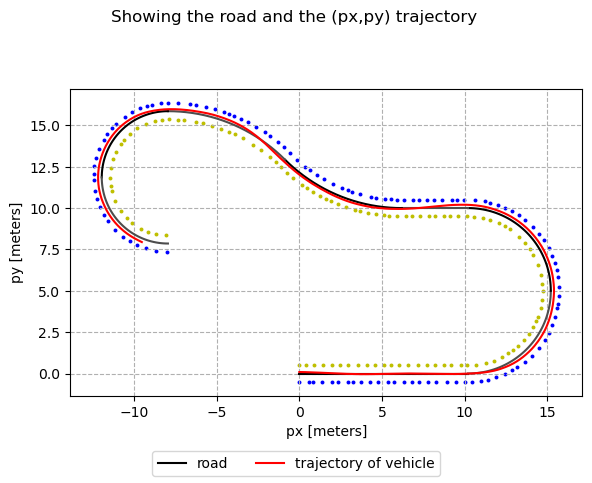

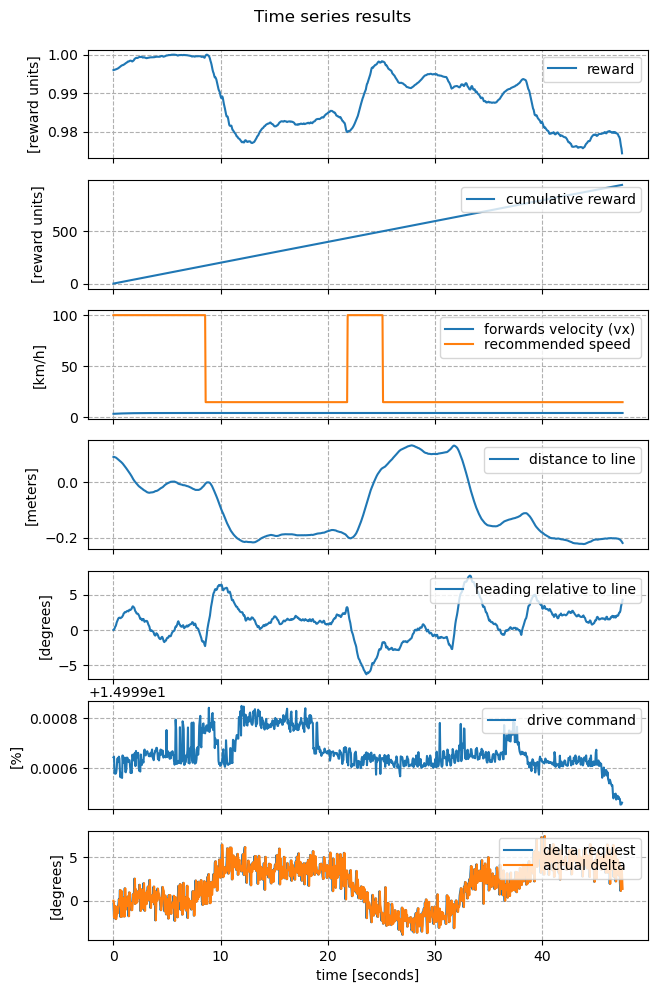

In [137]:
# Import the function for simulating the autonomous driving environment
from evaluation.evaluation_for_autonomous_driving import simulate_policy
from evaluation.evaluation_for_autonomous_driving import plot_results_from_time_series_dict

# Specify the length of the simulation in time steps
# > If termination or truncation is flagged by the "step" function,
#   Then, the simulation ends.
N_sim = 950

# Specify the seed for when the simulate function resets the random number generator
sim_seed = 1;

# Call the function for simulating a given policy
sim_time_series_dict = simulate_policy(env_eval, N_sim, rl_policy, seed=sim_seed, verbose=1)

# Call the plotting function
file_name_suffix = "example"
plot_details_list = plot_results_from_time_series_dict(env_base, sim_time_series_dict, path_for_saving_figures, file_name_suffix, should_plot_reward=True)

### Animate the time series results

We first define a function to make it easier to create animations. Then call the function for the simulation results produced in the previous cell.

In [138]:
def animate_from_sim_time_series_dict(sim_time_series_dict, Ts, path_for_saving_figures):
    # Extract the necessary trajectory information from the "sim_time_series_dict"
    px_traj    = sim_time_series_dict["px"]
    py_traj    = sim_time_series_dict["py"]
    theta_traj = sim_time_series_dict["theta"]
    delta_traj = sim_time_series_dict["delta"]
    # Call the environments function to create the simulation
    ani = env_eval.unwrapped.render_matplotlib_animation_of_trajectory(px_traj, py_traj, theta_traj, delta_traj, Ts, traj_increment=3, zoom_width=6, zoom_height=6)
    # Save the animation
    ani.save(f"{path_for_saving_figures}/trajectory_animation.gif")
    print(f'Saved animation at {path_for_saving_figures}/trajectory_animation.gif')
    # Return the animation object
    return ani

MovieWriter ffmpeg unavailable; using Pillow instead.


Saved animation at ../models/cone_following/eval/trajectory_animation.gif


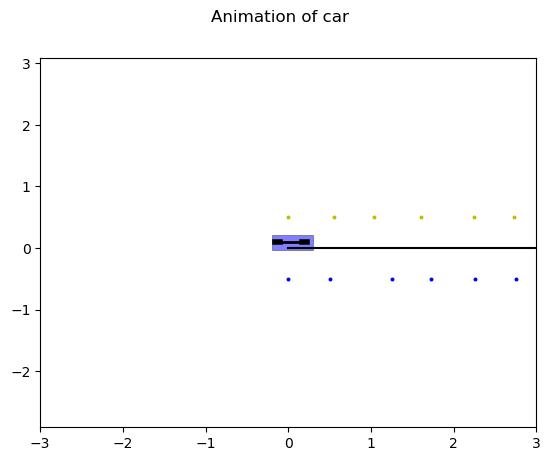

In [139]:
# Call the animation functoin
ani = animate_from_sim_time_series_dict(sim_time_series_dict, numerical_integration_parameters["Ts"], path_for_saving_figures)
# Display the animation
from IPython.display import HTML
HTML(ani.to_jshtml())